# Configurações e Coleta de Dados

In [25]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Carregar o dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')

# Fase 1: Análise Exploratória de Dados (EDA)

## Descritiva e Estatística

In [26]:
# Exibir informações estruturais
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")

# Exibir tipos de dados
print("\nTipos de dados de cada variável:")
print(df.dtypes)

# Exibir sumário estatístico
print("\nSumário estatístico descritivo:")
print(df.describe())

Total de linhas: 32581
Total de colunas: 12

Tipos de dados de cada variável:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Sumário estatístico descritivo:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000

## Visual

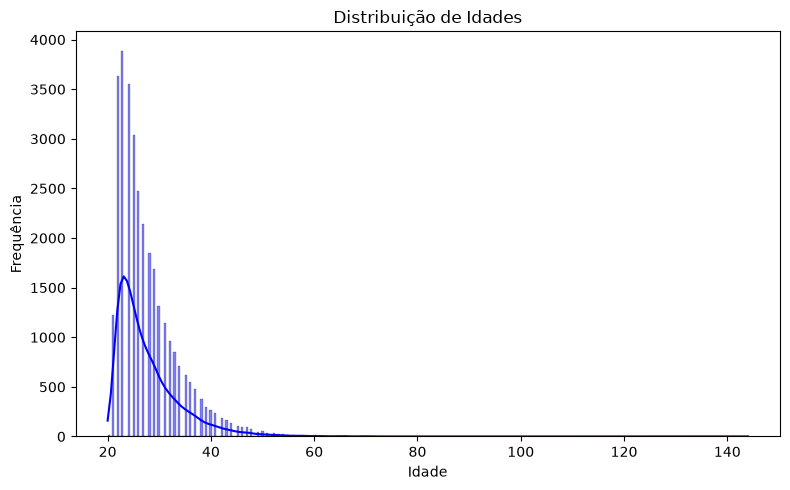

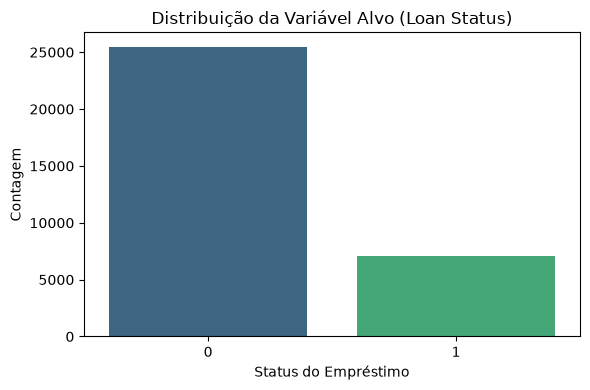

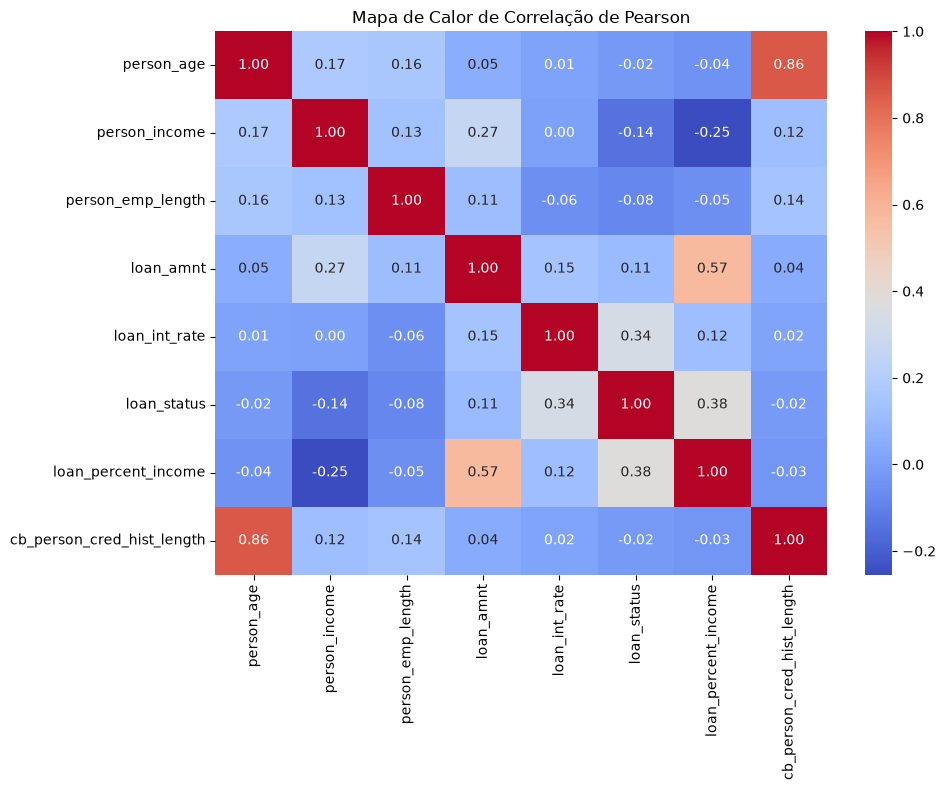

In [27]:
# 1. Histograma de Distribuição de Idades
plt.figure(figsize=(8, 5))
sns.histplot(df['person_age'], kde=True, color='blue')
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# 2. Gráfico de Barras: Desbalanceamento da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, hue='loan_status', palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (Loan Status)')
plt.xlabel('Status do Empréstimo')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show() # Exibe o gráfico diretamente na saída do notebook

# 3. Mapa de Calor de Correlação (Pearson)
plt.figure(figsize=(10, 8))
# Seleciona apenas colunas numéricas para calcular a correlação de Pearson
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlação de Pearson')
plt.tight_layout()
plt.show()

## Tomada de Decisão

A análise revelou que o dataset exige uma limpeza rigorosa. Primeiramente, é necessário remover ou corrigir os registros com idades e tempos de emprego irreais para garantir a sanidade estatística. Os valores nulos em loan_int_rate e person_emp_length serão tratados. Devido ao desbalanceamento visualizado na variável alvo, a estratégia de preparação incluirá técnicas de reamostragem ou ajuste de pesos na modelagem, para que o algoritmo não desenvolva um viés excessivo em favor da classe majoritária, garantindo a eficácia na detecção de fraudes ou calotes.

# Fase 2 : Tratamento e Limpeza (DATA PREP)

# Tratamento de Duplicadas

In [28]:
# Justificativa: A remoção de linhas duplicadas é essencial para evitar redundância.
df.drop_duplicates(inplace=True)
print("Linhas duplicadas removidas com sucesso.")

Linhas duplicadas removidas com sucesso.


# Tratamento de Valores Nulos

Justificativa: Utilizamos a Mediana para preencher valores ausentes nas colunas 'person_emp_length' e 'loan_int_rate'. Mediana é mais robusta, garantindo que o valor inserido seja estatisticamente representativo da tendência central dos dados.

In [35]:

colunas_nulas = ['person_emp_length', 'loan_int_rate']

for col in colunas_nulas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

print("Valores nulos tratados com a mediana.")

Valores nulos tratados com a mediana.


## Tratamento de Outliers

Justificativa: Identificamos valores irreais (outliers) via análise visual prévia. Optamos pela técnica de Clipping (limitação), que substitui valores extremos pelos limites calculados. Esta técnica preserva o volume da base de dados e é crucial para modelos como KNN, que calculam distâncias euclidianas e são altamente sensíveis a valores distorcidos.

In [36]:
def tratar_outliers_clipping(df, colunas):
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)
    return df

colunas_outliers = ['person_age', 'person_emp_length', 'loan_amnt']
df = tratar_outliers_clipping(df, colunas_outliers)
print("Outliers tratados via clipping.")

Outliers tratados via clipping.


# Fase 3: Feature Engineering

In [37]:
# Preenchemos com a mediana para manter a consistência
colunas_base = ['loan_amnt', 'person_income']

for col in colunas_base:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Evitamos divisão por zero caso a renda seja 0 (substituindo por um valor mínimo ou tratando)
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income'].replace(0, 1)) * 100

print("Coluna 'comprometimento_renda' criada com sucesso.")
# Verificação rápida
print(df[['loan_amnt', 'person_income', 'comprometimento_renda']].head())

Coluna 'comprometimento_renda' criada com sucesso.
   loan_amnt  person_income  comprometimento_renda
0      23125          59000              39.194915
1       1000           9600              10.416667
2       5500           9600              57.291667
3      23125          65500              35.305344
4      23125          54400              42.509191


# Fase 4: Separação, Balanceamento e Escalonamento Seguro

## Encoding

## Split de Dados

In [38]:
# Encoding: Transformando categorias em colunas numéricas (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

# Split: Separando X (preditores) e y (alvo)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Dividindo em Treino (80%) e Teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Split realizado com estratificação.")

Split realizado com estratificação.


## Balanceamento de Classes

In [39]:
from imblearn.over_sampling import SMOTE

# Aplicando SMOTE apenas no conjunto de treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanceamento concluído apenas no treino.")

Balanceamento concluído apenas no treino.


## Escalonamento Seguro

In [ ]:
from sklearn.preprocessing import StandardScaler

# Criando o scaler
scaler = StandardScaler()

# Ajustamos e transformamos apenas no treino
# Transformamos o teste usando a média e desvio do treino (evita vazamento)
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Dados escalonados para KNN. (Lembre-se: Árvore de Decisão aceita X_train_res/X_test direto)")

from sklearn.tree import DecisionTreeClassifier

# Modelo treinado com dados balanceados, porém SEM escalonamento
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)

print("Árvore de Decisão treinada com sucesso nos dados originais (sem escala).")

Dados escalonados para KNN. (Lembre-se: Árvore de Decisão aceita X_train_res/X_test direto)
Árvore de Decisão treinada com sucesso nos dados originais (sem escala).


# Fase 5: Modelagem e Validação (O Desafio do Overfitting)

## Otimização do KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn_resultados = []
valores_k = [3, 5, 7, 9]

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_res)

    # Avaliando
    train_score = knn.score(X_train_scaled, y_train_res)
    test_score = knn.score(X_test_scaled, y_test)

    knn_resultados.append({'K': k, 'Train_Acc': train_score, 'Test_Acc': test_score})

df_knn = pd.DataFrame(knn_resultados)
print("Resultados KNN:")
print(df_knn)

Resultados KNN:
   K  Train_Acc  Test_Acc
0  3   0.951607  0.876157
1  5   0.940131  0.885256
2  7   0.932777  0.887569
3  9   0.927397  0.887569


## Otimização da Árvore

In [45]:
from sklearn.tree import DecisionTreeClassifier

tree_resultados = []
profundidades = [3, 5, 7, None]

for depth in profundidades:
    # A Árvore não precisa de dados escalonados (X_train_res / X_test)
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train_res, y_train_res)

    train_score = tree.score(X_train_res, y_train_res)
    test_score = tree.score(X_test, y_test)

    tree_resultados.append({'Depth': depth, 'Train_Acc': train_score, 'Test_Acc': test_score})

df_tree = pd.DataFrame(tree_resultados)
print("\nResultados Árvore de Decisão:")
print(df_tree)


Resultados Árvore de Decisão:
   Depth  Train_Acc  Test_Acc
0    3.0   0.849193  0.866132
1    5.0   0.888530  0.890037
2    7.0   0.905854  0.904688
3    NaN   1.000000  0.885410


## Diagnóstico de Overfitting

Tabela de Diagnóstico de Overfitting:


,Depth,Train_Acc,Test_Acc,Gap
0,3,0.849193,0.866132,0.016939
1,5,0.888530,0.890037,0.001507
2,7,0.905854,0.904688,0.001166
3,None,1.000000,0.885410,0.114590


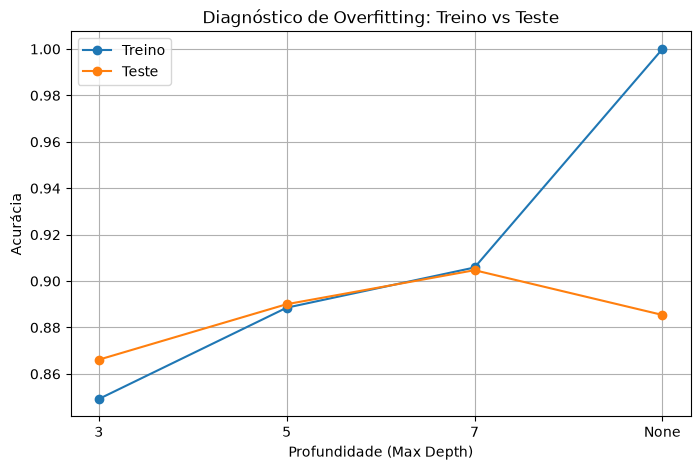

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Criando o DataFrame com os dados que você obteve
data = {
    'Depth': [3, 5, 7, 'None'],
    'Train_Acc': [0.849193, 0.888530, 0.905854, 1.000000],
    'Test_Acc': [0.866132, 0.890037, 0.904688, 0.885410]
}

df_resultados = pd.DataFrame(data)

# Calculando o Gap para o relatório
df_resultados['Gap'] = abs(df_resultados['Train_Acc'] - df_resultados['Test_Acc'])

# Exibindo a tabela formatada
print("Tabela de Diagnóstico de Overfitting:")
display(df_resultados)

# 2. Gerando o Gráfico para visualizar o Overfitting
plt.figure(figsize=(8, 5))
plt.plot(df_resultados['Depth'].astype(str), df_resultados['Train_Acc'], marker='o', label='Treino')
plt.plot(df_resultados['Depth'].astype(str), df_resultados['Test_Acc'], marker='o', label='Teste')

plt.title('Diagnóstico de Overfitting: Treino vs Teste')
plt.xlabel('Profundidade (Max Depth)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()